In [ ]:
# ECLAT

In [1]:
! pip install pandas pyECLAT


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np

# Simulated supermarket transaction dataset
# Example supermarket transactions
transactions = [
    ["Bread","Milk","Beer","Eggs","Butter"],
    ["Bread","Diaper","Beer","Coke","Chips"],
    ["Milk","Diaper","Beer","Coke","Bread"],
    ["Bread","Milk","Diaper","Beer","Butter"],
    ["Bread","Milk","Diaper","Coke","Eggs"],
    ["Milk","Beer","Chips","Bread","Butter"],
    ["Bread","Coke","Chips","Beer","Diaper"],
    ["Milk","Diaper","Beer","Butter","Eggs"],
    ["Bread","Milk","Beer","Coke","Chips"],
    ["Milk","Diaper","Bread","Butter","Eggs"]
]

# Create dataframe
df = pd.DataFrame(transactions)

# IMPORTANT: columns must be numeric for pyECLAT
df.columns = range(df.shape[1])

print("Dataset:")
print(df)

Dataset:
       0       1       2       3       4
0  Bread    Milk    Beer    Eggs  Butter
1  Bread  Diaper    Beer    Coke   Chips
2   Milk  Diaper    Beer    Coke   Bread
3  Bread    Milk  Diaper    Beer  Butter
4  Bread    Milk  Diaper    Coke    Eggs
5   Milk    Beer   Chips   Bread  Butter
6  Bread    Coke   Chips    Beer  Diaper
7   Milk  Diaper    Beer  Butter    Eggs
8  Bread    Milk    Beer    Coke   Chips
9   Milk  Diaper   Bread  Butter    Eggs


In [7]:
from pyECLAT import ECLAT

# Initialize ECLAT object
eclat = ECLAT(data=df)

# Get frequent itemsets
indices, support = eclat.fit(min_support=0.3,
                             min_combination=1,
                             max_combination=3,
                             separator=' & ')


Combination 1 by 1


8it [00:00, 127.95it/s]


Combination 2 by 2


28it [00:00, 187.13it/s]


Combination 3 by 3


56it [00:00, 230.77it/s]


In [8]:
print("Frequent Itemsets and their Support:\n")

for itemset, sup in support.items():
    print(itemset, ":", sup)

Frequent Itemsets and their Support:

Butter : 0.5
Eggs : 0.4
Milk : 0.8
Coke : 0.5
Beer : 0.8
Chips : 0.4
Diaper : 0.7
Bread : 0.9
Butter & Eggs : 0.3
Butter & Milk : 0.5
Butter & Beer : 0.4
Butter & Diaper : 0.3
Butter & Bread : 0.4
Eggs & Milk : 0.4
Eggs & Diaper : 0.3
Eggs & Bread : 0.3
Milk & Coke : 0.3
Milk & Beer : 0.6
Milk & Diaper : 0.5
Milk & Bread : 0.7
Coke & Beer : 0.4
Coke & Chips : 0.3
Coke & Diaper : 0.4
Coke & Bread : 0.5
Beer & Chips : 0.4
Beer & Diaper : 0.5
Beer & Bread : 0.7
Chips & Bread : 0.4
Diaper & Bread : 0.6
Butter & Eggs & Milk : 0.3
Butter & Milk & Beer : 0.4
Butter & Milk & Diaper : 0.3
Butter & Milk & Bread : 0.4
Butter & Beer & Bread : 0.3
Eggs & Milk & Diaper : 0.3
Eggs & Milk & Bread : 0.3
Milk & Coke & Bread : 0.3
Milk & Beer & Diaper : 0.3
Milk & Beer & Bread : 0.5
Milk & Diaper & Bread : 0.4
Coke & Beer & Chips : 0.3
Coke & Beer & Diaper : 0.3
Coke & Beer & Bread : 0.4
Coke & Chips & Bread : 0.3
Coke & Diaper & Bread : 0.4
Beer & Chips & Bread : 0.

In [10]:
# Put the result in dictionary and sort it by Support
result = pd.DataFrame({
    "Itemset": support.keys(),
    "Support": support.values()
})

print(result.sort_values(by="Support", ascending=False))


                   Itemset  Support
7                    Bread      0.9
4                     Beer      0.8
2                     Milk      0.8
6                   Diaper      0.7
19            Milk & Bread      0.7
26            Beer & Bread      0.7
28          Diaper & Bread      0.6
17             Milk & Beer      0.6
18           Milk & Diaper      0.5
25           Beer & Diaper      0.5
23            Coke & Bread      0.5
38     Milk & Beer & Bread      0.5
3                     Coke      0.5
9            Butter & Milk      0.5
0                   Butter      0.5
44   Coke & Diaper & Bread      0.4
45    Beer & Chips & Bread      0.4
39   Milk & Diaper & Bread      0.4
13             Eggs & Milk      0.4
12          Butter & Bread      0.4
10           Butter & Beer      0.4
1                     Eggs      0.4
5                    Chips      0.4
24            Beer & Chips      0.4
27           Chips & Bread      0.4
30    Butter & Milk & Beer      0.4
22           Coke & Diaper  

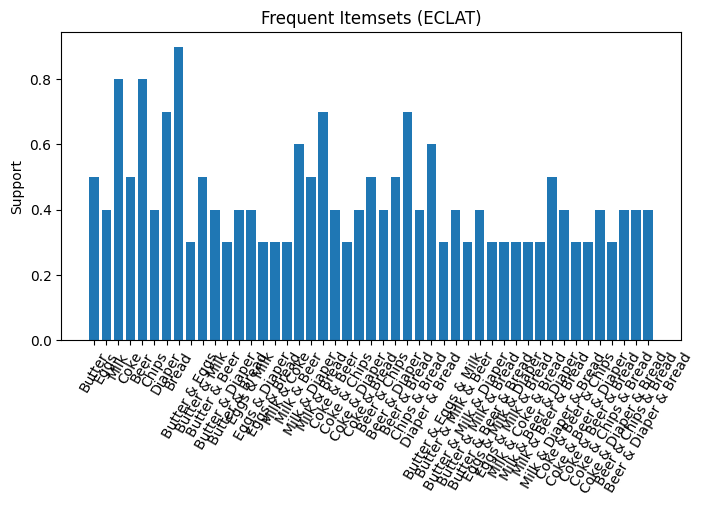

In [9]:
import matplotlib.pyplot as plt

items = list(support.keys())
values = list(support.values())

plt.figure(figsize=(8,4))
plt.bar(items, values)
plt.xticks(rotation=60)
plt.title("Frequent Itemsets (ECLAT)")
plt.ylabel("Support")
plt.show()
